# Day 4: Analyzing MESA Outputs II

In this notebook, we'll introduce two astropy modules that may be useful -- units and constants. We will walk through computing numerical derivatives. We will also walk through hydrostatic equilibrium again. 

Note: you may need to install mesa_reader on Google Colab or on your Jupyter notebook, by running a cell with 
"!pip install mesa_reader"

In [1]:
# this cell imports all the necessary libraries

import numpy as np

import matplotlib.pyplot as plt
import matplotlib as matplotlib

import mesa_reader as mr

## Astropy

Here we will introduce two useful astropy modules: units and constants. 

As you can guess, units is useful for unit conversions, whereas constants gives you useful physical constants.

In [14]:
# import these as u and const
import astropy.units as u
import astropy.constants as const

For example, you can access the gravitational constant G:

In [12]:
const.G

<<class 'astropy.constants.codata2018.CODATA2018'> name='Gravitational constant' value=6.6743e-11 uncertainty=1.5e-15 unit='m3 / (kg s2)' reference='CODATA 2018'>

Here the value is given in SI units. However, the annoying thing with astronomy is that most people use CGS units -- lengths in cm, mass in grams, etc. 

We can use the astropy units module to convert units. 

For example, the gravitational constant has units of $\rm{m}^{3} \, \rm{kg} \, \rm{s}^{-2}$. In CGS, meters ($\rm{m}$) would be in centimeters ($\rm{cm}$), and kilograms ($\rm{kg}$) would be in grams ($\rm{g}$). 

We use the .to() function to convert to other units. You would need to supply your desired units. In CGS, this would be $\rm{cm}^{3} \, \rm{g} \, \rm{s}^{-2}$. So the following gives you the conversion of the gravitational constant to CGS:

In [13]:
const.G.to(u.cm**3/u.g/u.s**2)

<Quantity 6.6743e-08 cm3 / (g s2)>

You can access its value like this:

In [15]:
const.G.to(u.cm**3/u.g/u.s**2).value

6.674299999999998e-08

This is quite a mouthful, so we can actually do something even faster:

In [16]:
const.G.cgs

<Quantity 6.6743e-08 cm3 / (g s2)>

or to access its value:

In [17]:
const.G.cgs.value

6.674299999999999e-08

## Numerical derivative

Here we quickly walk through how we take derivatives numerically. This will come up every now and then. 

Let's say we want to take the derivative of the function $y = x^{2}$. We know what this should look like: $dy/dx = 2 x$. 

We can also do this numerically using the numpy function `np.gradient`. Take a quick look below to see what it does. Pay particular attention to the examples. 

In [33]:
help(np.gradient)

Help on _ArrayFunctionDispatcher in module numpy:

gradient(f, *varargs, axis=None, edge_order=1)
    Return the gradient of an N-dimensional array.

    The gradient is computed using second order accurate central differences
    in the interior points and either first or second order accurate one-sides
    (forward or backwards) differences at the boundaries.
    The returned gradient hence has the same shape as the input array.

    Parameters
    ----------
    f : array_like
        An N-dimensional array containing samples of a scalar function.
    varargs : list of scalar or array, optional
        Spacing between f values. Default unitary spacing for all dimensions.
        Spacing can be specified using:

        1. single scalar to specify a sample distance for all dimensions.
        2. N scalars to specify a constant sample distance for each dimension.
           i.e. `dx`, `dy`, `dz`, ...
        3. N arrays to specify the coordinates of the values along each
           di

Now we show how this works in practice:

Text(0, 0.5, '$dy/dx$')

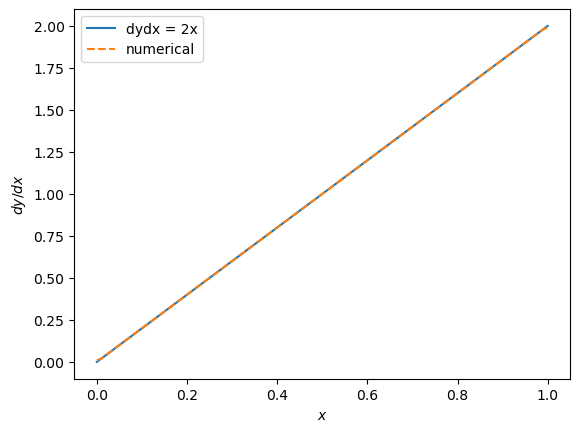

In [35]:
x = np.linspace(0,1,100)
y = x*x

# analytic derivative 
dydx_analytic = 2.*x

# numerical derivative
dydx_numerical = np.gradient(y,x)

# plot the results
plt.plot(x,dydx_analytic,label='dydx = 2x')
plt.plot(x,dydx_numerical,label='numerical',ls='--')

plt.legend()

plt.xlabel(r'$x$')
plt.ylabel(r'$dy/dx$')

You will need this in the next part. 

## Hydrostatic Balance

We will take a look at the very last profile of your first run, once again. You can download this  here {download}`first_run/profile8.data`

In [2]:
# load profile
myp = mr.MesaData('first_run/profile8.data')

As we showed last time, the pressure in a star is greatest at its center, and decreases towards the surface. This pressure gradient is what keeps a star from collapsing under its own gravity.

Let's check this for ourselves. For a star under hydrostatic balance, its structure satisfies the following equation:

$
\Large
\frac{dP}{dr} = - \frac{G m(r) \rho(r)}{r^{2}}
$

The left hand side is the pressure gradient, how rapidly the pressure changes with radius. 

In the right hand side, $G$ is the gravitational constant, $m(r)$ is the mass enclosed in each shell, and $\rho(r)$ is the density of each shell. The $(r)$ denotes that both the mass enclosed and the local density change with radius $r$. 

The pressure profile $P(r)$, mass enclosed $m(r)$, density $\rho(r)$, and radius itself $r$, are both available in the profile:

In [36]:
myp.bulk_names

('zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'pp',
 'cno',
 'tri_alpha')

### Your task:

- Compute $dP/dr$ numerically using the `np.gradient` function, and plot $dP/dr$ as a function of radius $r$. 
- Compute $-G m(r) \rho(r) / r^{2}$, and plot it as a function of radius $r$, on the same plot as $dP/dr$.
- Show the plot in log scale on the $y$-axis, using `plt.semilogy()`.
- Compare the two and make sure that they agree with each other.

Note: 
- Everything that goes into $dP/dr$ and $-G m(r) \rho(r) / r^{2}$ should be in cgs units.
- The `logR` and `mass` quantities in the profile are given in solar units, so you would need a conversion using the astropy `constants` module.

In [38]:
# work here

We will go through the following in person.

## Derivation of equation of hydrostatic equilibrium

Consider a shell that has an inner radius $r$ and outer radius $r + dr$ (such that its thickness is $dr$). 

The density of the shell is $\rho(r)$ ("rho"), such that the mass of the shell is $dm = 4 \pi r^{2} \rho(r) dr$. And we denote the mass enclosed by the shell, $m(r)$. We note that both $\rho(r)$ and $m(r)$ are functions of radius/distance from center. 

<br><br>
There are pressure forces acting on this shell. If the pressure at the inner shell is $P$, and the pressure at the outer shell is $P + dP$, then the net pressure force acting on the shell is 

$
\Large
F_{\rm pressure} = P \cdot A - (P + dP ) \cdot A = - dP \cdot A
$

where $A = 4 \pi r^{2} $ is the area of the shell 
(recall that pressure is force per area). 


<br><br>
Gravity also acts on the shell:

$
\Large F_{\rm gravity} = - \frac{G m(r) dm}{r^{2}} .
$


<br><br>
In equilibrium, the forces balance each other:

$
\Large
F_{\rm pressure} + F_{\rm gravity} = 0 \to 
$

$
\Large - dP \cdot A - \frac{G m(r) dm}{r^{2}} = 0
$
<br><br>

If we write out $A = 4 \pi r^{2}$, and $dm = 4 \pi r^{2} \rho(r) dr$, then we have 

$
\Large - dP \cdot 4 \pi r^{2} - \frac{G m(r) 4 \pi r^{2} \rho(r) dr}{ r^{2} } = 0
$

$
\Large - dP - \frac{G m(r) \rho(r) }{ r^{2} } dr = 0
$

$
\Large \frac{dP}{dr} = - \frac{G m(r) \rho(r) }{ r^{2} }.
$